In [1546]:
import pandas as pd

In [1547]:
df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")
df.info()

df_copy = df.copy()

C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_60\1263138397.py:1: DtypeWarning: Columns (0: cc_contractor_sentiment_start_score_cc, 1: cc_contractor_sentiment_end_score_cc) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../dataset/05_merged/final_latest_calls_fullcols.csv")


<class 'pandas.DataFrame'>
RangeIndex: 122082 entries, 0 to 122081
Columns: 122 entries, Co_Ref to Call_Year_cc
dtypes: float64(26), int64(10), object(4), str(82)
memory usage: 113.6+ MB


In [1548]:
len(df.columns)

122

In [1549]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

null_dict = null_percent.to_dict()
print(null_dict)

{'Churn_Category_renewal': 99.11944430792418, 'Complaint_Category_renewal': 97.94810045706984, 'cc_issues_within_questionnaire_cc': 97.44843629691519, 'cc_contractor_suggest_leave_cc': 97.4148523123802, 'cc_contractor_complained_cc': 97.4148523123802, 'cc_contractor_sentiment_cc': 97.4148523123802, 'cc_agent_cross_sell_attempt_cc': 97.4115758260841, 'cc_care_package_cc': 97.4115758260841, 'cc_urgency_getting_on_site_cc': 97.4115758260841, 'cc_external_consultant_cc': 97.4115758260841, 'cc_business_struggles_financial_hardship_cc': 97.4115758260841, 'cc_call_initiated_by_cc': 97.4115758260841, 'cc_customer_issues_concerns_cc': 97.4115758260841, 'cc_care_package_discussed_cc': 97.4115758260841, 'cc_dissatisfaction_time_to_complete_cc': 97.40748021821398, 'cc_platform_issues_cc': 97.40748021821398, 'cc_login_issues_cc': 97.40748021821398, 'cc_dissatisfaction_support_cc': 97.40748021821398, 'cc_questions_harder_than_expected_cc': 97.40748021821398, 'cc_process_complexity_concerns_cc': 97.4

In [1550]:
null_percent = (df.isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

# filter > 75%
high_null_dict = null_percent[null_percent > 70].to_dict()

print(high_null_dict)

{'Churn_Category_renewal': 99.11944430792418, 'Complaint_Category_renewal': 97.94810045706984, 'cc_issues_within_questionnaire_cc': 97.44843629691519, 'cc_contractor_suggest_leave_cc': 97.4148523123802, 'cc_contractor_complained_cc': 97.4148523123802, 'cc_contractor_sentiment_cc': 97.4148523123802, 'cc_agent_cross_sell_attempt_cc': 97.4115758260841, 'cc_care_package_cc': 97.4115758260841, 'cc_urgency_getting_on_site_cc': 97.4115758260841, 'cc_external_consultant_cc': 97.4115758260841, 'cc_business_struggles_financial_hardship_cc': 97.4115758260841, 'cc_call_initiated_by_cc': 97.4115758260841, 'cc_customer_issues_concerns_cc': 97.4115758260841, 'cc_care_package_discussed_cc': 97.4115758260841, 'cc_dissatisfaction_time_to_complete_cc': 97.40748021821398, 'cc_platform_issues_cc': 97.40748021821398, 'cc_login_issues_cc': 97.40748021821398, 'cc_dissatisfaction_support_cc': 97.40748021821398, 'cc_questions_harder_than_expected_cc': 97.40748021821398, 'cc_process_complexity_concerns_cc': 97.4

In [1551]:
cols_drop_95 = [col for col, val in high_null_dict.items() if val > 95]
df = df.drop(columns=cols_drop_95)

In [1552]:
import numpy as np

# ── 1. Explicit Switching Intent ─────────────────────────────
col = 'Explicit_Switching_Intent_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')   # handle NULL first
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes': 'Yes',
        'no': 'No',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 2. Discount Offered ─────────────────────────────────────
col = 'Discount_Offered_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'yes': 'Yes',
        'no': 'No',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 3. Customer Response ────────────────────────────────────
col = 'Customer_Response_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'positive': 'Positive',
        'negative': 'Negative',
        'neutral': 'Neutral',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)


# ── 4. Desire To Cancel ─────────────────────────────────────
col = 'Desire_To_Cancel_renewal'
df[col] = (
    df[col]
    .replace(np.nan, 'Unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        'renewed': 'Renew',
        'renew': 'Renew',
        'desired to cancel': 'Cancel',
        'unknown': 'Unknown'
    })
    .fillna('Unknown')
)



import numpy as np

# Generic cleaner + encoder
def binary_encode(col, mapping):
    return (
        df[col]
        .replace(np.nan, 'Unknown')
        .astype(str)
        .str.strip()
        .str.lower()
        .map(mapping)
        .fillna(0)   # Unknown → 0 (no signal)
    )


# ── 1. Explicit Switching Intent ─────────────────────────────
df['Explicit_Switching_Intent_flag'] = binary_encode(
    'Explicit_Switching_Intent_renewal',
    {
        'yes': 1,
        'no': 0,
        'unknown': 0
    }
)


# ── 2. Discount Offered ─────────────────────────────────────
df['Discount_Offered_flag'] = binary_encode(
    'Discount_Offered_renewal',
    {
        'yes': 1,
        'no': 0,
        'unknown': 0
    }
)


# ── 3. Customer Response (convert to NEGATIVE signal) ────────
df['Customer_Response_flag'] = binary_encode(
    'Customer_Response_renewal',
    {
        'negative': 1,   # churn signal
        'positive': 0,
        'neutral': 0,
        'unknown': 0
    }
)


# ── 4. Desire To Cancel ─────────────────────────────────────
df['cancel_flag'] = binary_encode(
    'Desire_To_Cancel_renewal',
    {
        'desired to cancel': 1,
        'cancel': 1,
        'renew': 0,
        'renewed': 0,
        'unknown': 0
    }
)

df = df.drop(columns=[
    'Explicit_Switching_Intent_renewal',
    'Discount_Offered_renewal',
    'Customer_Response_renewal',
    'Desire_To_Cancel_renewal'
])

In [1553]:
print(df['cancel_flag'].value_counts())

cancel_flag
0    120474
1      1608
Name: count, dtype: int64


In [1554]:
important_sparse_cols = [
    col for col, val in high_null_dict.items()
    if 80 < val <= 95
]

print(important_sparse_cols)

['Agent_Response_Category_renewal', 'Customer_Renewal_Response_Category_renewal', 'Agent_Renewal_Pitch_Category_renewal', 'Serious_Complaint_renewal', 'Other_Complaint_renewal', 'Competitor_Benefits_Mentioned_renewal', 'Membership_Renewal_Decision_renewal', 'Discount_or_Waiver_Requested_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Discussion_on_Price_Increase_renewal', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Agent_Renewal_Initiation_renewal', 'Call_Reschedule_Request_renewal', 'Price_Switching_Mentioned_renewal', 'Explicit_Switching_Intent_renewal', 'Mentioned_Competitors_renewal', 'Explicit_Competitor_Mention_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Price_Range_Mentioned_renewal', 'Percentage_Price_Increase_Mentioned_renewal', 'Topic_Introduced_By_renewal', 'Customer_Response_renewal', 'Desire_To_Cancel_renewal', 'Customer_Asked_For_Justification_renewal', 'Discount_Offered_renewal', 'Analysed_Call_renewal']


In [1555]:
# Drop known useless columns
drop_cols = [
    'Co_Ref',
    'Call_ID_renewal',
    'Contact_ID_cc',
    'Call_Date_renewal',
    'Prospect_Renewal_Date'
]

df = df.drop(columns=[col for col in drop_cols if col in df.columns])

In [1556]:
len(df.columns)
print(df.columns)

Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Closed_Date',
       'Prospect_Status', 'Starting_Net', 'Starting_Vat', 'Starting_Gross',
       'Starting_Membership_Net', 'Starting_Package_Net', 'Starting_PQQ_Net',
       'Gross', 'Membership_Net', 'Package_Net', 'PQQNet', 'Total_Net_Paid',
       'Prospect_Outcome', 'Payment_Method', 'Amount', 'Total_Amount',
       'Connection_Group', 'Tenure_Group', '#_of_Connection', 'La

In [1557]:
drop_cols += [
    'Starting_Vat',
    'Starting_Gross',
    'Starting_Membership_Net',
    'Starting_Package_Net',
    'Starting_PQQ_Net',
    'Starting_Net',
    'Gross',
    'Membership_Net',
    'Package_Net',
    'PQQNet',
    'Amount'
]

df = df.drop(columns = drop_cols , errors='ignore')

In [1558]:
# keep_cat = [
#     'Payment_Method',
#     'Band',
#     'Connection_Group',
#     'Tenure_Group',
#     'Anchor_Group'
# ]

len(df.columns)

print(df.columns)

Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Proforma_Date',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Registration_Date', 'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Closed_Date',
       'Prospect_Status', 'Total_Net_Paid', 'Prospect_Outcome',
       'Payment_Method', 'Total_Amount', 'Connection_Group', 'Tenure_Group',
       '#_of_Connection', 'Last_Renewal', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year', 'DateTime_Out',
       'Prev_Renewal_Date', 'Call_Direction_renewal',
       'Agent_Renew

In [1559]:
df['target'] = df['Prospect_Outcome'].map({
    'Won': 0,
    'Churned': 1
})

df = df.drop(columns=['Prospect_Outcome'])

In [1560]:
drop_cols = [
    'Call_Number_renewal'
]

In [1561]:
# Convert to datetime
df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')

# Create feature
df['days_since_registration'] = (
    df['Closed_Date'] - df['Registration_Date']
).dt.days

C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_60\3293522358.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Closed_Date'] = pd.to_datetime(df['Closed_Date'], errors='coerce')
C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_60\3293522358.py:3: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Registration_Date'] = pd.to_datetime(df['Registration_Date'], errors='coerce')


In [1562]:
date_cols = [
    'Proforma_Date',
    'Registration_Date',
    'Closed_Date',
    'Last_Renewal',
    'Prev_Renewal_Date',
    'DateTime_Out',
    # 'Payment_Method',
]
df = df.drop(columns=date_cols)

In [1563]:
print(len(df.columns))

print(df.columns)


67
Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Payment_Method', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', '#_of_Connection', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year',
       'Call_Direction_renewal', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
       'Member

In [1564]:
# Create encoded column
df['Call_attend_status_renewal'] = (
    df['Call_Direction_renewal']
    .fillna('unknown')
    .astype(str)
    .str.strip()
    .str.lower()
    .apply(lambda x: 0 if x == 'inbound' else 1)
)

# Crosstab using NEW column
print(df['Call_attend_status_renewal'].value_counts())

# Now drop old column (optional)
df = df.drop(columns=['Call_Direction_renewal'], errors='ignore')

Call_attend_status_renewal
1    120543
0      1539
Name: count, dtype: int64



==== Payment_Method ====

target            0.0    1.0
Payment_Method              
BACS            100.0    0.0
CARD             93.2    6.8
CHEQUE          100.0    0.0
UNKNOWN           0.0  100.0
WORLD PAY       100.0    0.0

Counts:
 Payment_Method
CARD         71101
BACS         33191
UNKNOWN      16020
WORLD PAY     1699
CHEQUE          71
Name: count, dtype: int64


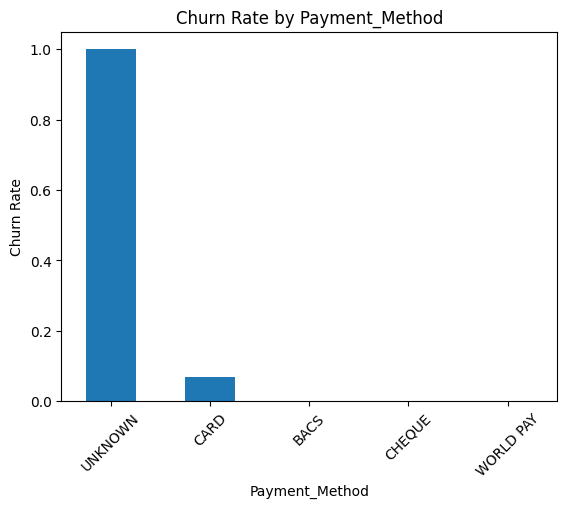


==== Band ====

target     0.0    1.0
Band                 
Band A   77.94  22.06
Band B   82.64  17.36
Band C1  89.02  10.98
Band C2  91.74   8.26
Band D   92.91   7.09
Band E   93.57   6.43
Band F   93.66   6.34
Band F1  93.82   6.18
Band F2  93.30   6.70
Band G   93.35   6.65
Band H   93.24   6.76
Band I   91.78   8.22
Band J   93.37   6.63
Group    94.19   5.81
Unknown   5.00  95.00

Counts:
 Band
Band B     32731
Band C1    24922
Band D     18965
Band C2    15765
Band E      9652
Band F1     5905
Band A      3764
Band F2     3184
Band G      2391
Band F      2193
Group        986
Band H       823
Band J       397
Band I       380
Unknown       24
Name: count, dtype: int64


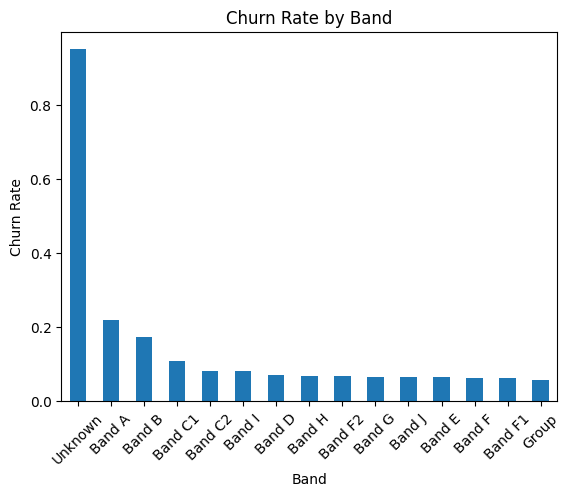


==== Connection_Group ====

target              0.0    1.0
Connection_Group              
1                 85.99  14.01
10+               97.77   2.23
2                 91.57   8.43
3                 94.11   5.89
4-9               96.12   3.88
Unknown           41.80  58.20
independent       80.13  19.87

Counts:
 Connection_Group
1              38137
independent    25088
4-9            20607
2              19408
3              10463
10+             8253
Unknown          126
Name: count, dtype: int64


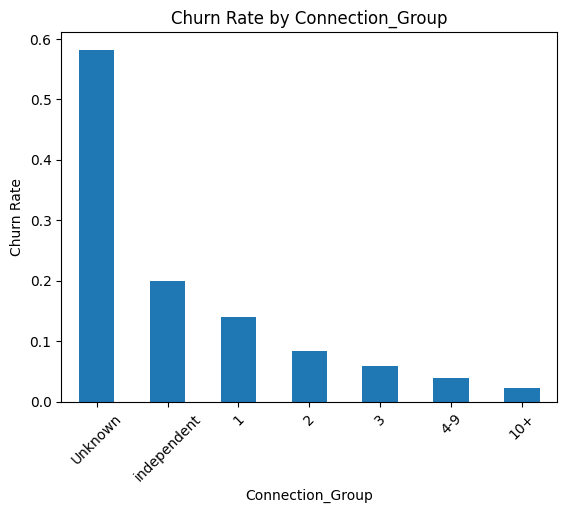


==== Tenure_Group ====

target          0.0    1.0
Tenure_Group              
1             78.19  21.81
2             84.00  16.00
3             86.23  13.77
4+            92.87   7.13
Unknown       87.59  12.41

Counts:
 Tenure_Group
4+         76327
1          19543
2          14175
3          11019
Unknown     1018
Name: count, dtype: int64


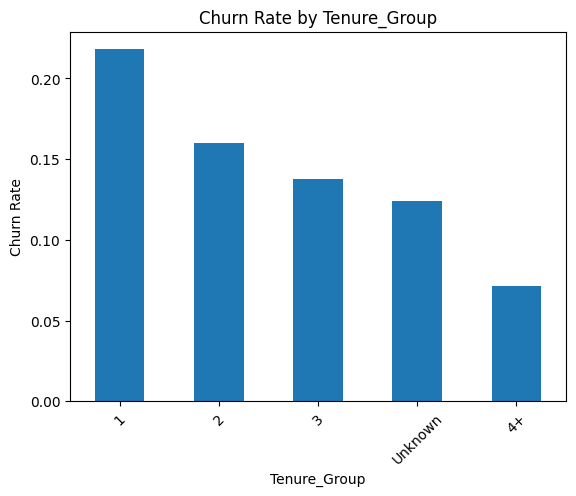


==== Anchor_Group ====

target          0.0    1.0
Anchor_Group              
1             85.99  14.01
10+           97.77   2.23
2             91.57   8.43
3             94.11   5.89
4-9           96.12   3.88
Unknown       41.80  58.20
independent   80.13  19.87

Counts:
 Anchor_Group
1              38137
independent    25088
4-9            20607
2              19408
3              10463
10+             8253
Unknown          126
Name: count, dtype: int64


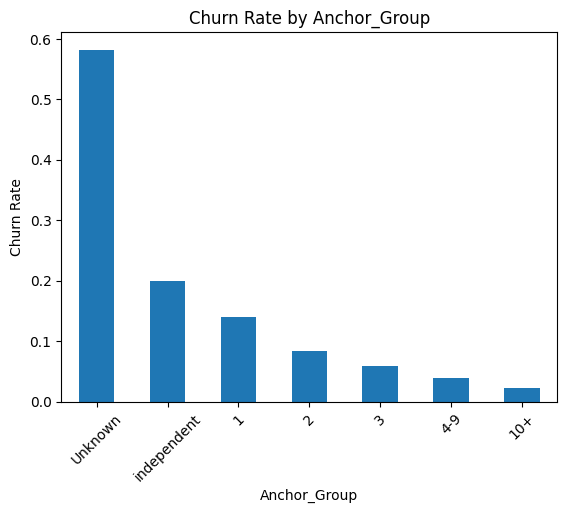

In [1565]:
import matplotlib.pyplot as plt

cat_cols = [
    'Payment_Method',
    'Band',
    'Connection_Group',
    'Tenure_Group',
    'Anchor_Group',
]

for col in cat_cols:
    print(f"\n==== {col} ====\n")
    
    # ── Handle missing values (important) ────────────────
    df[col] = df[col].fillna('Unknown')
    
    # ── Crosstab (% distribution) ───────────────────────
    ct = pd.crosstab(df[col], df['target'], normalize='index') * 100
    print(ct.round(2))
    
    # ── Add count (VERY IMPORTANT for interpretation) ───
    count = df[col].value_counts()
    print("\nCounts:\n", count)
    
    # ── Churn Rate ─────────────────────────────────────
    churn_rate = (
        df.groupby(col)['target']
        .mean()
        .sort_values(ascending=False)
    )
    
    # ── Plot ───────────────────────────────────────────
    plt.figure()
    churn_rate.plot(kind='bar')
    plt.title(f"Churn Rate by {col}")
    plt.ylabel("Churn Rate")
    plt.xlabel(col)
    plt.xticks(rotation=45)
    plt.show()

In [1566]:
from scipy.stats import chi2_contingency

cat_cols = [
    'Payment_Method',
    'Band',
    'Connection_Group',
    'Tenure_Group',
    'Anchor_Group',
   
]

results = []

for col in cat_cols:
    # Create contingency table
    table = pd.crosstab(df[col], df['target'])
    
    # Apply Chi-square test
    chi2, p, dof, expected = chi2_contingency(table)
    
    results.append((col, chi2, p))

# Convert to DataFrame
res_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'p_value'])

# Sort by significance
res_df = res_df.sort_values('p_value')

print(res_df)

            Feature          Chi2  p_value
0    Payment_Method  68301.191365      0.0
1              Band   2721.465259      0.0
2  Connection_Group   4420.240766      0.0
3      Tenure_Group   3628.833560      0.0
4      Anchor_Group   4420.240766      0.0


In [1567]:
print(df.columns)

Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Payment_Method', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', '#_of_Connection', 'Last_Band', 'Last_Total_Net_Paid',
       'Last_Connections', 'Anchor_Group', 'Renewal_Year',
       'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
       'Membership_Renewal_Decision_renewal

In [1568]:
cols = [ '#_of_Connection', 'Last_Connections', 'Connection_Group' ]

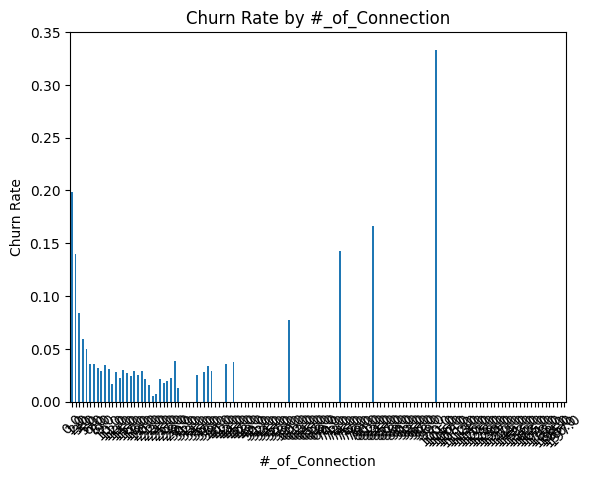

In [1569]:
import matplotlib.pyplot as plt

churn_rate = df.groupby('#_of_Connection')['target'].mean().sort_index()

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by #_of_Connection")
plt.ylabel("Churn Rate")
plt.xlabel("#_of_Connection")
plt.xticks(rotation=45)
plt.show()

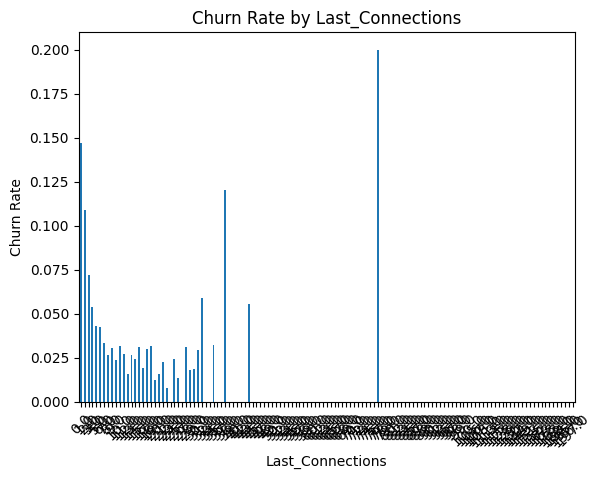

In [1570]:
churn_rate = df.groupby('Last_Connections')['target'].mean().sort_index()

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Last_Connections")
plt.ylabel("Churn Rate")
plt.xlabel("Last_Connections")
plt.xticks(rotation=45)
plt.show()

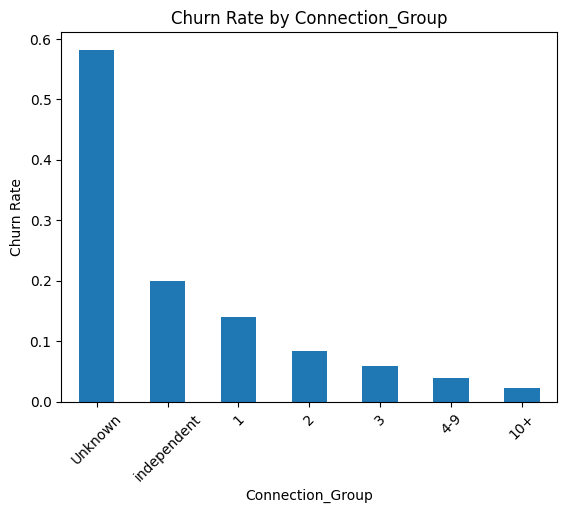

In [1571]:
churn_rate = df.groupby('Connection_Group')['target'].mean().sort_values(ascending=False)

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Connection_Group")
plt.ylabel("Churn Rate")
plt.xlabel("Connection_Group")
plt.xticks(rotation=45)
plt.show()

In [1572]:
from scipy.stats import pointbiserialr

cols = ['#_of_Connection', 'Last_Connections']

for col in cols:
    print(f"\n==== {col} ====\n")
    
    # Drop nulls just in case
    temp = df[[col, 'target']].dropna()
    
    corr, p = pointbiserialr(temp['target'], temp[col])
    
    print("Correlation:", round(corr, 4))
    print("p-value:", p)


==== #_of_Connection ====

Correlation: -0.1018
p-value: 1.5031852555032884e-259

==== Last_Connections ====

Correlation: -0.0846
p-value: 5.3707841702483874e-107


In [1573]:
df = df.drop(columns=['#_of_Connection', 'Last_Connections' , 'Payment_Method'])

In [1574]:
len(df.columns)

print(df.columns)

Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Account_Stage', 'Proforma_Audit_Status',
       'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token',
       'Renewal_Score_At_Release', 'Proforma_Membership_Status',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Prospect_Status',
       'Total_Net_Paid', 'Total_Amount', 'Connection_Group', 'Tenure_Group',
       'Last_Band', 'Last_Total_Net_Paid', 'Anchor_Group', 'Renewal_Year',
       'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal',
       'Membership_Renewal_Decision_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal'

In [1575]:
print(df['Membership_Renewal_Decision_renewal'].value_counts())

Membership_Renewal_Decision_renewal
No        15488
Yes        1224
Yes/No        1
Name: count, dtype: int64


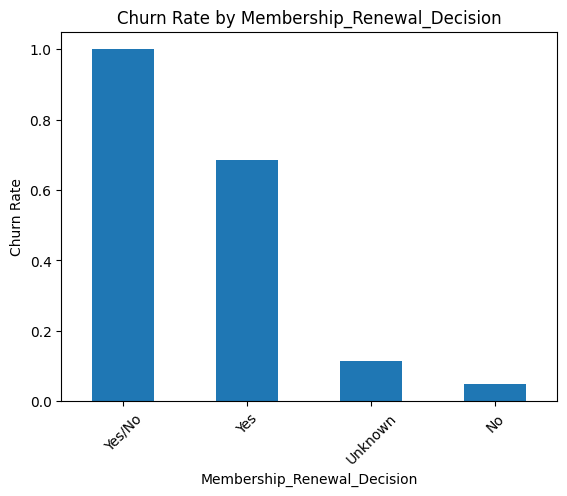

In [1576]:
import matplotlib.pyplot as plt

# Clean column
df['Membership_Renewal_Decision_renewal'] = (
    df['Membership_Renewal_Decision_renewal']
    .fillna('Unknown')
    .astype(str)
    .str.strip()
)

# Churn rate
churn_rate = (
    df.groupby('Membership_Renewal_Decision_renewal')['target']
    .mean()
    .sort_values(ascending=False)
)

plt.figure()
churn_rate.plot(kind='bar')
plt.title("Churn Rate by Membership_Renewal_Decision")
plt.ylabel("Churn Rate")
plt.xlabel("Membership_Renewal_Decision")
plt.xticks(rotation=45)
plt.show()

In [1577]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df['Membership_Renewal_Decision_renewal'],
    df['target']
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi2:", chi2)
print("p-value:", p)

Chi2: 4648.220910063991
p-value: 0.0


In [1578]:
# Yes/No → ~100% churn 🚨
# Yes → ~70% churn ⚠️
# Unknown → ~10%
# No → ~5%

# 👉 This is an extremely strong separation

In [1579]:
df = df.drop(columns=['Membership_Renewal_Decision_renewal'], errors='ignore')

In [1580]:
df['Analysed_Call_renewal'].value_counts()


Analysed_Call_renewal
1.0    17128
Name: count, dtype: int64

In [1581]:
df = df.drop(columns=['Analysed_Call_renewal'])

In [1582]:

print(df['Last_Band'].value_counts())
print(df['Band'].value_counts())

Last_Band
Band B     18315
Band C1    15049
Band D     11857
Band C2     9982
Band E      6133
Band F1     3344
Band F      2041
Band A      1971
Band F2     1829
Band G      1555
Group        664
Band H       524
Band I       277
Band J       230
Name: count, dtype: int64
Band
Band B     32731
Band C1    24922
Band D     18965
Band C2    15765
Band E      9652
Band F1     5905
Band A      3764
Band F2     3184
Band G      2391
Band F      2193
Group        986
Band H       823
Band J       397
Band I       380
Unknown       24
Name: count, dtype: int64


In [1583]:
cols = [
    'Mentioned_Competitors_renewal',
    'Competitor_Benefits_Mentioned_renewal',
    'Topic_Introduced_By_renewal'
]

for col in cols:
    print(f"\n==== {col} ====")
    print(df[col].value_counts(dropna=False))


==== Mentioned_Competitors_renewal ====
Mentioned_Competitors_renewal
NaN                                                                                                     104962
No                                                                                                       15765
Yes                                                                                                       1352
44. The customer also mentioned that Safe Contractor's product is not like-for-like with the others.         1
XXXX                                                                                                         1
5% price increase is "quite a hefty hike for no additional benefit for us".                                  1
Name: count, dtype: int64

==== Competitor_Benefits_Mentioned_renewal ====
Competitor_Benefits_Mentioned_renewal
NaN                                                 105397
Not Applicable                                       12417
Not Discussed                   

In [1584]:
# # ───────────────────────────────────────────────────────────
# # Handle competitor + topic columns (final version)
# # ───────────────────────────────────────────────────────────

# # 1. Mentioned Competitors → flag
# df['competitor_mentioned_flag'] = df['Mentioned_Competitors_renewal'].notnull().astype(int)

# # 2. Drop messy high-cardinality column
# df = df.drop(columns=['Competitor_Benefits_Mentioned_renewal'], errors='ignore')

# # 3. Topic Introduced By → clean + encode
# df['Topic_Introduced_By_renewal'] = df['Topic_Introduced_By_renewal'].fillna('Unknown')

# df = pd.get_dummies(
#     df,
#     columns=['Topic_Introduced_By_renewal'],
#     drop_first=True
# )

# # 4. Drop original competitor column
# df = df.drop(columns=['Mentioned_Competitors_renewal'], errors='ignore')

# # ───────────────────────────────────────────────────────────
# # Done: 
# # - competitor_mentioned_flag created
# # - noisy column removed
# # - topic column encoded
# # ───────────────────────────────────────────────────────────


==== Mentioned_Competitors_renewal ====
target                                                 0.0    1.0
Mentioned_Competitors_renewal                                    
44. The customer also mentioned that Safe Contr...  100.00   0.00
5% price increase is "quite a hefty hike for no...  100.00   0.00
NaN                                                  88.59  11.41
No                                                   91.16   8.84
XXXX                                                100.00   0.00
Yes                                                  83.23  16.77


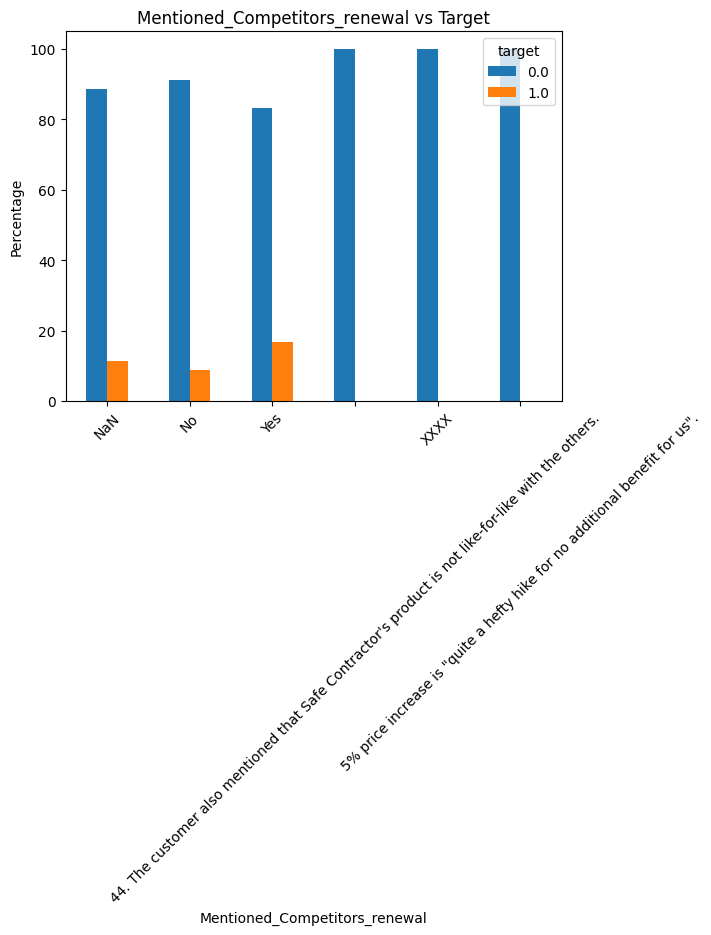


==== Competitor_Benefits_Mentioned_renewal ====
target                                                0.0    1.0
Competitor_Benefits_Mentioned_renewal                           
Advice                                              100.0    0.0
Assistance                                          100.0    0.0
Better Accreditation                                100.0    0.0
Better Offering                                     100.0    0.0
Better Price                                         75.0   25.0
...                                                   ...    ...
The customer mentions that they can get better ...  100.0    0.0
The customer mentions that they can get similar...    0.0  100.0
The customer mentions that they were expecting ...  100.0    0.0
The customer mentions using the ECA for risk as...  100.0    0.0
better service                                      100.0    0.0

[86 rows x 2 columns]


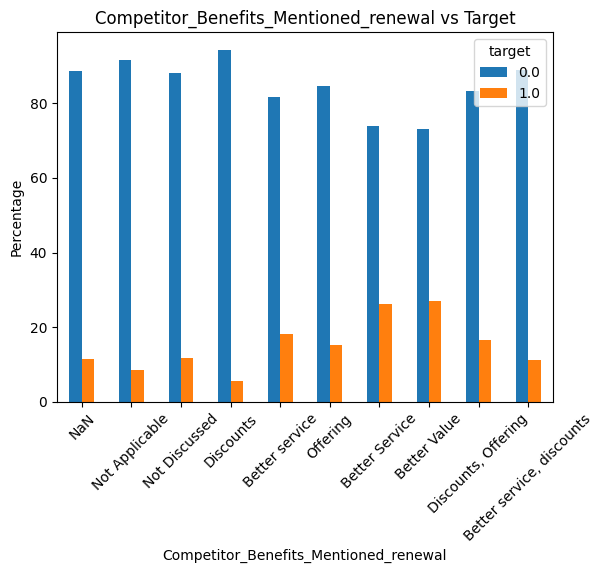


==== Topic_Introduced_By_renewal ====
target                         0.0    1.0
Topic_Introduced_By_renewal              
Agent                        92.69   7.31
Customer                     86.61  13.39
NaN                          88.59  11.41
Not Discussed                90.19   9.81


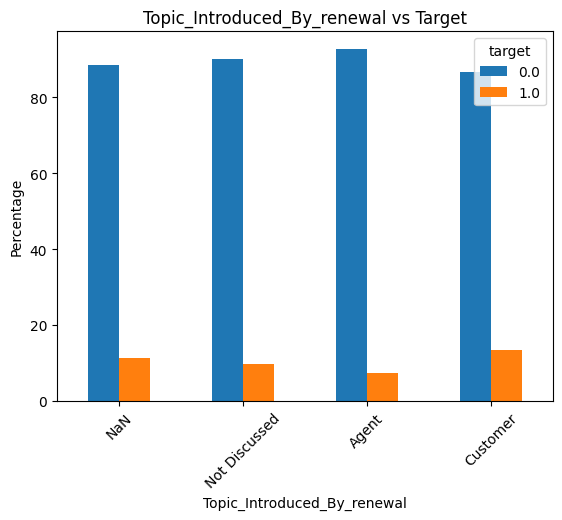


=== Chi-Square Results ===
                                 Feature  Chi2_Score       p_value
1  Competitor_Benefits_Mentioned_renewal  291.687224  1.867679e-24
0          Mentioned_Competitors_renewal  134.567009  2.552805e-27
2            Topic_Introduced_By_renewal   93.186187  4.529811e-20


In [1585]:
import matplotlib.pyplot as plt
import pandas as pd
from scipy.stats import chi2_contingency

cols = [
    'Mentioned_Competitors_renewal',
    'Competitor_Benefits_Mentioned_renewal',
    'Topic_Introduced_By_renewal'
]

results = []

for col in cols:
    
    if col not in df.columns:
        print(f"\n⚠️ Skipping {col} (not in df)")
        continue
    
    print(f"\n==== {col} ====")
    
    # Crosstab
    ct = pd.crosstab(df[col].fillna('NaN'), df['target'], normalize='index') * 100
    print(ct.round(2))
    
    # Plot top 10
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    ct_top = ct.loc[top_vals]
    
    ct_top.plot(kind='bar')
    plt.title(f'{col} vs Target')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()
    
    # Chi-square
    contingency = pd.crosstab(df[col].fillna('NaN'), df['target'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    results.append({
        'Feature': col,
        'Chi2_Score': chi2,
        'p_value': p
    })

chi_df = pd.DataFrame(results).sort_values(by='Chi2_Score', ascending=False)

print("\n=== Chi-Square Results ===")
print(chi_df)

In [1586]:
# competitor signal
df['competitor_mentioned_flag'] = df['Mentioned_Competitors_renewal'].notnull().astype(int)

# topic signal
df['topic_customer_flag'] = (df['Topic_Introduced_By_renewal'] == 'Customer').astype(int)

# optional
df['topic_agent_flag'] = (df['Topic_Introduced_By_renewal'] == 'Agent').astype(int)

In [1587]:
df = df.drop(columns=[
    'Competitor_Benefits_Mentioned_renewal',
    'Mentioned_Competitors_renewal',
    'Topic_Introduced_By_renewal'
], errors='ignore')

In [1588]:
# When a customer mentions competitors, it usually means:

# Comparing alternatives
# Evaluating switching
# Price dissatisfaction
# Value concerns

# 💥 All are strong churn signals


==== Prospect_Status ====
target                       0.0    1.0
Prospect_Status                        
Renewed                   100.00   0.00
Application and Money In   99.98   0.02
Renewal Proforma Sent      17.65  82.35
No Longer Trading           6.28  93.72
Do Not Work for Client      2.10  97.90
Not Value for Money         1.59  98.41
Refused to Discuss          1.53  98.47
Competitor Accreditation    2.24  97.76
Attempted Contact         100.00   0.00
Intention to Proceed      100.00   0.00


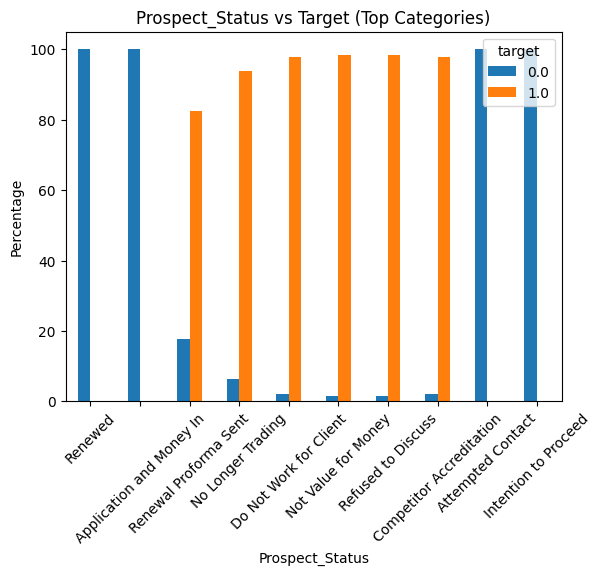


==== Proforma_Account_Stage ====
target                    0.0     1.0
Proforma_Account_Stage               
Published               93.84    6.16
Membership Only         70.04   29.96
Renewal Process         89.76   10.24
NaN                     86.91   13.09
Vetting                 68.79   31.21
Suspended               88.06   11.94
Retired                  0.00  100.00
vetting                  0.00  100.00


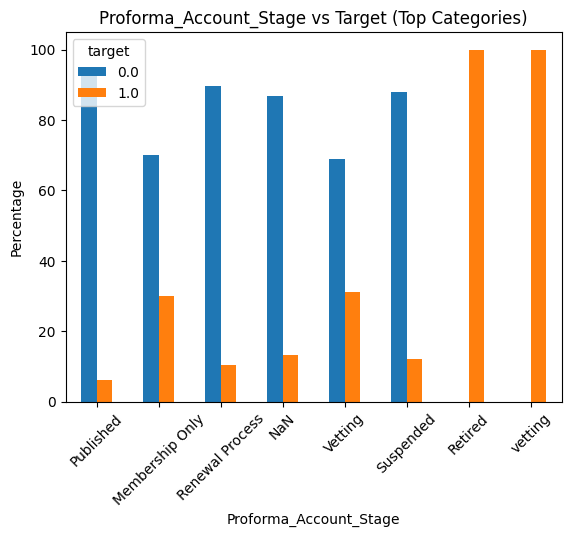


==== Proforma_Audit_Status ====
target                                                0.0    1.0
Proforma_Audit_Status                                           
Accredited                                          93.86   6.14
NaN                                                 86.91  13.09
Failed- Renewal Questionnaire not received          72.57  27.43
Renewal Questionnaire Received                      91.61   8.39
Failed- Renewal Additional Information Not Rece...  74.47  25.53
Failed- Initial additional info not received        67.20  32.80
Renewal Questionnaire Sent                          92.11   7.89
Failed- Initial Questionnaire not received          63.08  36.92
Initial Questionnaire Received                      67.23  32.77
Renewal report sent - Awaiting information          89.17  10.83


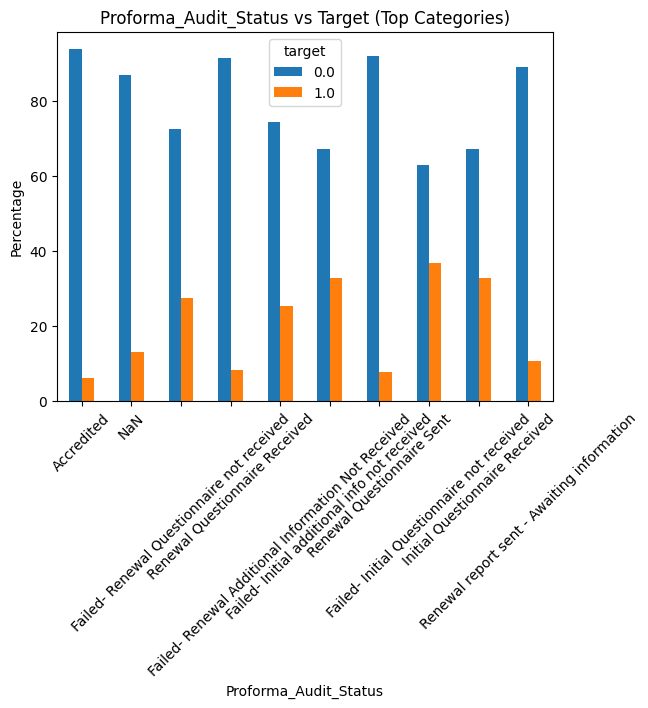

In [1589]:
import matplotlib.pyplot as plt
import pandas as pd

cols = [
    'Prospect_Status',
    'Proforma_Account_Stage',
    'Proforma_Audit_Status'
]

for col in cols:
    
    if col not in df.columns:
        print(f"\n⚠️ Skipping {col}")
        continue
    
    print(f"\n==== {col} ====")
    
    # Take top 10 categories for readability
    top_vals = df[col].fillna('NaN').value_counts().head(10).index
    
    # Crosstab (%)
    ct = pd.crosstab(
        df[col].fillna('NaN'),
        df['target'],
        normalize='index'
    ) * 100
    
    ct_top = ct.loc[top_vals]
    
    print(ct_top.round(2))
    
    # Plot
    ct_top.plot(kind='bar')
    plt.title(f'{col} vs Target (Top Categories)')
    plt.xlabel(col)
    plt.ylabel('Percentage')
    plt.xticks(rotation=45)
    plt.show()

In [1590]:
cols = [
    # 'Membership_Renewal_Decision_renewal',
    'Prospect_Status',
    'Proforma_Account_Stage',
    'Proforma_Audit_Status'
]

for col in cols:
     print(df[col].value_counts())
     print()

Prospect_Status
Renewed                                            94826
Application and Money In                            5897
Renewal Proforma Sent                               5219
No Longer Trading                                   2387
Do Not Work for Client                              2377
Not Value for Money                                 2196
Refused to Discuss                                  1180
Competitor Accreditation                             984
Attempted Contact                                    925
Intention to Proceed                                 722
Non Responsive                                       698
Not Affordable                                       612
Contact Made                                         576
Existing Safecontractor Member                       436
Cannot Pass Audit                                    413
Not to be contacted                                  409
Contact Made Deciding                                375
Potential Lost 

In [1591]:
df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].str.strip().str.title()

counts = df['Proforma_Account_Stage'].value_counts()

rare = counts[counts < 100].index

df['Proforma_Account_Stage'] = df['Proforma_Account_Stage'].replace(rare, 'Other')

In [1592]:
df['stage_high_risk_flag'] = df['Proforma_Account_Stage'].isin([
    'Membership Only',
    'Vetting'
]).astype(int)

df['stage_low_risk_flag'] = (df['Proforma_Account_Stage'] == 'Published').astype(int)

In [1593]:
df = df.drop(columns=['Prospect_Status'])
df = df.drop(columns=['Proforma_Account_Stage'])

In [1594]:
print(len(df.columns))

62


In [1595]:
print(df.columns)
print(len(df.columns))

Index(['Renewal_Month', 'Discount_Amount', 'Sustainability_Score',
       'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score',
       'Status_Scores', 'Anchoring_Score', 'Tenure_Scores',
       'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token',
       'Current_Anchorings', 'Current_Anchor_List', 'Payment_Timeframe',
       'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release',
       'Proforma_Membership_Status', 'Proforma_Approved_Lists', 'Tenure_Years',
       'Band', 'Total_Net_Paid', 'Total_Amount', 'Connection_Group',
       'Tenure_Group', 'Last_Band', 'Last_Total_Net_Paid', 'Anchor_Group',
       'Renewal_Year', 'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal', 'Discussion_on_Price_Increase_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
 

In [1596]:
extra_in_df = set(df.columns) - set(df_copy.columns)
print("Extra in df:", extra_in_df)

Extra in df: {'competitor_mentioned_flag', 'target', 'days_since_registration', 'cancel_flag', 'topic_customer_flag', 'Discount_Offered_flag', 'Explicit_Switching_Intent_flag', 'stage_low_risk_flag', 'topic_agent_flag', 'Customer_Response_flag', 'Call_attend_status_renewal', 'stage_high_risk_flag'}


In [1597]:
dropped_cols = list(set(df_copy.columns) - set(df.columns))
print("Dropped columns:", dropped_cols)

Dropped columns: ['Co_Ref', 'cc_login_issues_cc', 'Customer_Response_renewal', 'cc_agent_cross_sell_attempt_cc', 'Topic_Introduced_By_renewal', 'Membership_Net', 'Competitor_Benefits_Mentioned_renewal', 'Complaint_Category_renewal', 'cc_customer_issues_concerns_cc', 'Payment_Method', 'Desire_To_Cancel_renewal', 'cc_business_struggles_financial_hardship_cc', 'Starting_Package_Net', 'Package_Net', 'cc_chasing_response_cc', 'cc_pricing_mentioned_cc', 'Prospect_Status', 'cc_questions_harder_than_expected_cc', 'Membership_Renewal_Decision_renewal', 'Mentioned_Competitors_renewal', 'Prev_Renewal_Date', 'cc_issues_within_questionnaire_cc', 'cc_external_consultant_cc', 'Churn_Category_renewal', 'cc_call_initiated_by_cc', 'cc_process_complexity_concerns_cc', 'cc_contractor_sentiment_end_score_cc', 'cc_contractor_sentiment_issues_score_cc', 'cc_questionnaire_completion_cc', 'cc_contractor_sentiment_cc', 'Starting_Net', 'Explicit_Switching_Intent_renewal', 'cc_care_package_cc', 'PQQNet', 'Amount'

In [1598]:
# redundancy in total agent flag 


df = df.drop(columns=['topic_agent_flag'], errors='ignore')

# 👉 These two are correlated / redundant

# Because:

# If customer = 1 → agent = 0
# If agent = 1 → customer = 0

# 👉 Model gets duplicate information


In [1599]:
extra_in_df = set(df.columns) - set(df_copy.columns)
# print("Extra in df:", extra_in_df)

print(set(df.columns) - set(extra_in_df))
print(len(set(df.columns) - set(extra_in_df)))

{'Other_Complaint_renewal', 'Proforma_Audit_Status', 'Discount_or_Waiver_Requested_renewal', 'Total_Amount', 'Tenure_Years', 'Sustainability_Score', 'Call_Number_renewal', 'Current_Anchor_List', 'Connection_Group', 'Last_Total_Net_Paid', 'Renewal_Year', 'Proforma_Membership_Status', 'Total_Net_Paid', 'Tenure_Group', 'Auto_Renewal_Score', 'Customer_Asked_For_Justification_renewal', 'Renewal_Score_At_Release', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Proforma_Approved_Lists', 'Current_Auto_Renewal_Flag', 'Last_Band', 'Percentage_Price_Increase_Mentioned_renewal', 'Customer_Renewal_Response_Category_renewal', 'Anchoring_Score', 'Call_Reschedule_Request_renewal', 'Explicit_Competitor_Mention_renewal', 'Current_Anchorings', 'Renewal_Month', 'Total_Renewal_Score_New', 'Status_Scores', 'Band', 'Price_Range_Mentioned_renewal', 'Anchor_Group', 'Payment_Timeframe', 'Call_Year_renewal', 'Price_Switching_Mentioned_renewal', 'Agent_Renewal_Pitch

In [1600]:
print(df['Call_Number_renewal'].value_counts())

Call_Number_renewal
1.0      14849
2.0       8101
3.0       3600
4.0       1855
5.0        986
6.0        628
7.0        438
8.0        311
9.0        224
10.0       187
11.0       116
12.0       111
13.0        75
14.0        72
15.0        55
16.0        49
17.0        38
18.0        26
19.0        19
20.0        19
23.0        16
21.0        13
24.0        12
25.0        11
22.0         9
31.0         9
26.0         8
27.0         7
32.0         6
29.0         6
35.0         5
34.0         4
38.0         4
30.0         4
33.0         3
28.0         3
45.0         2
39.0         2
43.0         2
36.0         2
165.0        1
51.0         1
44.0         1
59.0         1
41.0         1
53.0         1
47.0         1
46.0         1
66.0         1
85.0         1
40.0         1
Name: count, dtype: int64


In [1601]:
x = [
    'Call_Number_renewal',
    'Call_Year_renewal',
]

df = df.drop(columns = x)

In [1602]:
x = [
    'Renewal_Month',
    'Renewal_Year'
]

df = df.drop(columns = x)



In [1603]:
extra_in_df = set(df.columns) - set(df_copy.columns)
# print("Extra in df:", extra_in_df)

print(set(df.columns) - set(extra_in_df))
print(len(set(df.columns) - set(extra_in_df)))

{'Other_Complaint_renewal', 'Proforma_Audit_Status', 'Discount_or_Waiver_Requested_renewal', 'Total_Amount', 'Tenure_Years', 'Sustainability_Score', 'Current_Anchor_List', 'Connection_Group', 'Last_Total_Net_Paid', 'Proforma_Membership_Status', 'Total_Net_Paid', 'Tenure_Group', 'Auto_Renewal_Score', 'Customer_Asked_For_Justification_renewal', 'Renewal_Score_At_Release', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Proforma_Approved_Lists', 'Current_Auto_Renewal_Flag', 'Last_Band', 'Percentage_Price_Increase_Mentioned_renewal', 'Customer_Renewal_Response_Category_renewal', 'Anchoring_Score', 'Call_Reschedule_Request_renewal', 'Explicit_Competitor_Mention_renewal', 'Current_Anchorings', 'Total_Renewal_Score_New', 'Status_Scores', 'Band', 'Price_Range_Mentioned_renewal', 'Anchor_Group', 'Payment_Timeframe', 'Price_Switching_Mentioned_renewal', 'Agent_Renewal_Pitch_Category_renewal', 'Last_Years_Price', 'Agent_Response_Category_renewal', 'P

In [1604]:
print(len(df.columns))

57


In [1605]:
print(df['Payment_Timeframe'].value_counts())

Payment_Timeframe
 0.0      28880
-1.0       3014
 1.0       2936
-2.0       2045
 2.0       1989
          ...  
 153.0        1
-297.0        1
-193.0        1
-689.0        1
-247.0        1
Name: count, Length: 295, dtype: int64


In [1606]:
df['Payment_Timeframe'] = np.sign(df['Payment_Timeframe']) * np.log1p(abs(df['Payment_Timeframe']))

In [1607]:
print(df['Payment_Timeframe'].value_counts())

Payment_Timeframe
 0.000000    28880
-0.693147     3014
 0.693147     2936
-1.098612     2045
 1.098612     1989
             ...  
 5.036953        1
-5.697093        1
-5.267858        1
-6.536692        1
-5.513429        1
Name: count, Length: 295, dtype: int64


# =============================================================================================

In [1608]:
num_cols = df.select_dtypes(include=['number']).columns.tolist()
print(num_cols)
print(len(num_cols))

['Sustainability_Score', 'Total_Renewal_Score_New', 'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores', 'Anchoring_Score', 'Tenure_Scores', 'Current_Anchorings', 'Payment_Timeframe', 'Renewal_Score_At_Release', 'Proforma_Approved_Lists', 'Tenure_Years', 'Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'Explicit_Switching_Intent_flag', 'Discount_Offered_flag', 'Customer_Response_flag', 'cancel_flag', 'target', 'days_since_registration', 'Call_attend_status_renewal', 'competitor_mentioned_flag', 'topic_customer_flag', 'stage_high_risk_flag', 'stage_low_risk_flag']
26


In [1609]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(cat_cols)
print(len(cat_cols))

['Discount_Amount', 'Proforma_Auto_Renewal', 'Proforma_World_Pay_Token', 'Current_Anchor_List', 'Proforma_Audit_Status', 'Current_Auto_Renewal_Flag', 'Current_World_Pay_Token', 'Proforma_Membership_Status', 'Band', 'Connection_Group', 'Tenure_Group', 'Last_Band', 'Anchor_Group', 'Agent_Renewal_Pitch_Category_renewal', 'Customer_Renewal_Response_Category_renewal', 'Agent_Response_Category_renewal', 'Serious_Complaint_renewal', 'Other_Complaint_renewal', 'Discussion_on_Price_Increase_renewal', 'Renewal_Impact_Due_to_Price_Increase_renewal', 'Discount_or_Waiver_Requested_renewal', 'Call_Reschedule_Request_renewal', 'Agent_Flagged_Membership_Status_Alert_renewal', 'Agent_Renewal_Initiation_renewal', 'Explicit_Competitor_Mention_renewal', 'Price_Switching_Mentioned_renewal', 'Competitor_Value_Comparison_renewal', 'Percentage_Price_Increase_Mentioned_renewal', 'Monetary_Price_Increase_Mentioned_renewal', 'Price_Range_Mentioned_renewal', 'Customer_Asked_For_Justification_renewal']
31


C:\Users\NidharsanVelmurugan\AppData\Local\Temp\ipykernel_60\1926294870.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


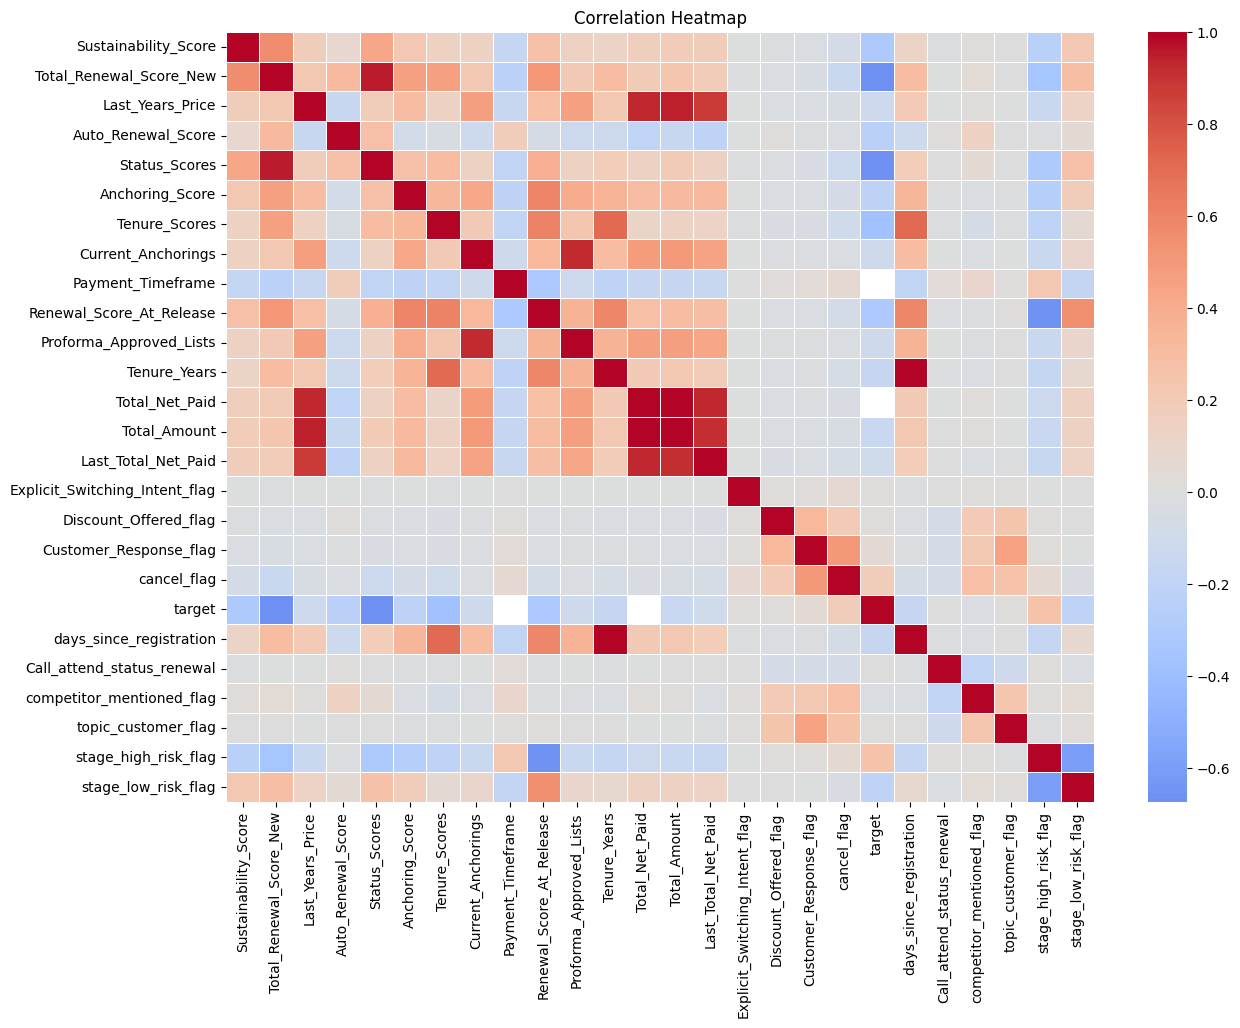

In [1610]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr,
    annot=False,        # set True if you want numbers (but cluttered)
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

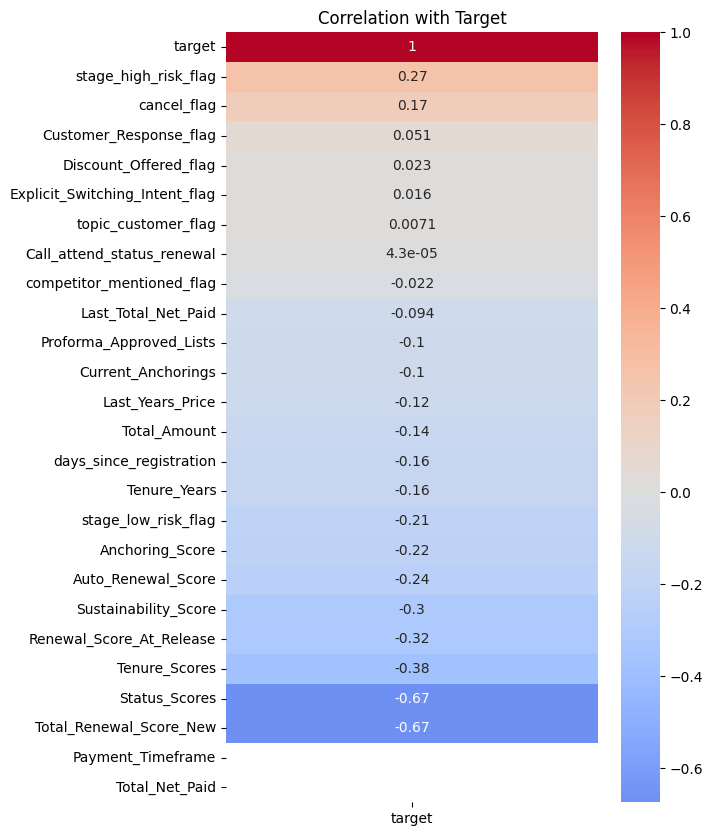

In [1611]:
corr_target = df.corr(numeric_only=True)[['target']].sort_values(by='target', ascending=False)

plt.figure(figsize=(6, 10))
sns.heatmap(
    corr_target,
    annot=True,
    cmap='coolwarm',
    center=0
)

plt.title("Correlation with Target")
plt.show()

In [1612]:
import numpy as np

corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [col for col in upper.columns if any(upper[col] > 0.9)]

print("Highly correlated:", high_corr)

Highly correlated: ['Status_Scores', 'Proforma_Approved_Lists', 'Total_Net_Paid', 'Total_Amount', 'Last_Total_Net_Paid', 'days_since_registration']


In [1613]:
# ✅ 1. Financial cluster (VERY CLEAR)
drop = ['Total_Amount', 'Last_Total_Net_Paid']

df = df.drop(columns=drop, errors='ignore')



# 👉 These are almost duplicates

# ✔ Keep ONLY 1–2

In [1614]:
# 👉 Highly correlated with:

# Tenure_Years
# ✔ Keep ONLY ONE

# Prefer:

keep = ['Tenure_Years']
drop = ['days_since_registration']

df.drop(columns=drop, errors='ignore', inplace=True)

# 👉 Easier interpretation + cleaner

In [1615]:
print(len(df.columns))

54


In [1616]:
from scipy.stats import chi2_contingency



results = []

for col in cat_cols:
    table = pd.crosstab(df[col], df['target'])
    
    chi2, p, _, _ = chi2_contingency(table)
    
    results.append((col, chi2, p))

chi_df = pd.DataFrame(results, columns=['Feature', 'Chi2', 'p_value'])
chi_df = chi_df.sort_values('p_value')

print(chi_df)

                                          Feature          Chi2        p_value
0                                 Discount_Amount  11791.651459   0.000000e+00
6                         Current_World_Pay_Token   6588.385138   0.000000e+00
5                       Current_Auto_Renewal_Flag   2380.948863   0.000000e+00
4                           Proforma_Audit_Status   9229.385339   0.000000e+00
7                      Proforma_Membership_Status   8700.121536   0.000000e+00
10                                   Tenure_Group   3628.833560   0.000000e+00
9                                Connection_Group   4420.240766   0.000000e+00
8                                            Band   2721.465259   0.000000e+00
15                Agent_Response_Category_renewal   3065.750992   0.000000e+00
14     Customer_Renewal_Response_Category_renewal   3190.508311   0.000000e+00
12                                   Anchor_Group   4420.240766   0.000000e+00
11                                      Last_Band   

In [1617]:
# [
#     'Discount_Amount',
#     'Current_World_Pay_Token',
#     'Current_Auto_Renewal_Flag',
#     'Proforma_Audit_Status',              # ⚠️ possible leakage
#     'Proforma_Membership_Status',         # ❌ likely leakage
#     'Connection_Group',
#     'Anchor_Group',
#     'Tenure_Group',
#     'Band',
#     'Agent_Response_Category_renewal',
#     'Customer_Renewal_Response_Category_renewal'
# ]




# 🚨 2. STRONG BUT CHECK FOR LEAKAGE
# [
#     'Proforma_Audit_Status',
#     'Proforma_Membership_Status'
# ]

# 👉 These are too strong → suspicious

# ❌ Recommendation:
# drop_cols += [
#     'Proforma_Audit_Status',
#     'Proforma_Membership_Status'
# ]

In [1618]:
# 👉 From your Chi-square:

# Very low Chi2 ❌
# High p-values ❌
# Weak signal ❌

# 👉 That means:

# They are weak predictors, regardless of direction


df = df.drop(columns=[
    'Proforma_Audit_Status',
    'Proforma_Membership_Status',
    'Discussion_on_Price_Increase_renewal',
    'Agent_Flagged_Membership_Status_Alert_renewal',
    'Monetary_Price_Increase_Mentioned_renewal',
    'Customer_Asked_For_Justification_renewal',
    'Percentage_Price_Increase_Mentioned_renewal',
    'Price_Range_Mentioned_renewal'
], errors='ignore')

In [1619]:
print(len(df.columns))

46


In [1620]:
print(len(df.columns))
print(df.columns)

46
Index(['Discount_Amount', 'Sustainability_Score', 'Total_Renewal_Score_New',
       'Last_Years_Price', 'Auto_Renewal_Score', 'Status_Scores',
       'Anchoring_Score', 'Tenure_Scores', 'Proforma_Auto_Renewal',
       'Proforma_World_Pay_Token', 'Current_Anchorings', 'Current_Anchor_List',
       'Payment_Timeframe', 'Current_Auto_Renewal_Flag',
       'Current_World_Pay_Token', 'Renewal_Score_At_Release',
       'Proforma_Approved_Lists', 'Tenure_Years', 'Band', 'Total_Net_Paid',
       'Connection_Group', 'Tenure_Group', 'Last_Band', 'Anchor_Group',
       'Agent_Renewal_Pitch_Category_renewal',
       'Customer_Renewal_Response_Category_renewal',
       'Agent_Response_Category_renewal', 'Serious_Complaint_renewal',
       'Other_Complaint_renewal',
       'Renewal_Impact_Due_to_Price_Increase_renewal',
       'Discount_or_Waiver_Requested_renewal',
       'Call_Reschedule_Request_renewal', 'Agent_Renewal_Initiation_renewal',
       'Explicit_Competitor_Mention_renewal',
       '

In [ ]:
# Still Reduce
# https://chatgpt.com/s/t_69dd0783f9f48191b440da3615b3d47a